# 循環神經網路的從零開始實現
:label:`sec_rnn_scratch`

本節將根據 :numref:`sec_rnn`中的描述，
從頭開始基於循環神經網路實現字符級語言模型。
這樣的模型將在H.G.Wells的時光機器數據集上訓練。
和前面 :numref:`sec_language_model`中介紹過的一樣，
我們先讀取數據集。


In [2]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
import time
import numpy as np

In [1]:
import math
import torch
import time 
from torch import nn
import torch.nn.functional as F
import numpy as np

def get_params(vocab_size, num_hiddens, device):
    """初始化模型參數"""
    num_inputs = num_outputs = vocab_size
    
    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01
    
    # 隱藏層參數
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    # 輸出層參數
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    
    # 附加梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

def init_rnn_state(batch_size, num_hiddens, device):
    """初始化隱藏狀態"""
    return (torch.zeros((batch_size, num_hiddens), device=device),)

def rnn(inputs, state, params):
    """RNN前向計算"""
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

def grad_clipping(net, theta):
    """梯度裁剪"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm
class RNNModelScratch:
    """從零開始實現的循環神經網路模型"""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn
        self.device = device

    def __call__(self, X, state=None):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size):
        return self.init_state(batch_size, self.num_hiddens, self.device)
def load_time_machine_data():
    """加載時光機器數據集"""
    import requests
    import os
    
    # 檢查文件是否存在
    if not os.path.exists('time_machine.txt'):
        # 嘗試不同的URL
        urls = [
            'https://raw.githubusercontent.com/d2l-ai/d2l-zh/master/d2l/data/timemachine.txt',
            'https://raw.githubusercontent.com/d2l-ai/d2l-en/master/d2l/data/timemachine.txt'
        ]
        
        success = False
        for url in urls:
            try:
                response = requests.get(url)
                response.raise_for_status()  # 檢查下載是否成功
                content = response.content.decode('utf-8')
                # 檢查內容是否包含 "404" 或太短
                if "404" not in content and len(content) > 100:
                    with open('time_machine.txt', 'w', encoding='utf-8') as f:
                        f.write(content)
                    print(f"成功從 {url} 下載數據集")
                    success = True
                    break
            except Exception as e:
                print(f"從 {url} 下載失敗: {e}")
                continue
       
        if not success:
            print("所有下載嘗試都失敗了")
            return None, None, None
    
    try:
        # 讀取文件
        with open('time_machine.txt', 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        # 處理文本：移除標點符號和換行符，轉換為小寫
        text = ' '.join([line.strip().lower() for line in lines])
        text = ''.join(ch for ch in text if ch.isalnum() or ch.isspace())
        
        # 如果文本太短，僅給出警告但仍繼續使用數據
        if len(text) < 100:
            print("警告：文本內容太短，可能不是正確的數據集，但仍繼續使用該數據集")
        
        # 打印一些統計信息
        print(f"原始文本長度: {len(text)}")
        print(f"前100個字符預覽: {text[:100]}")
        
        # 創建詞表
        chars = sorted(list(set(text)))
        print(f"詞表大小: {len(chars)}")
        char_to_idx = {char: i for i, char in enumerate(chars)}
        idx_to_char = {i: char for i, char in enumerate(chars)}
        
        # 文本轉換為索引
        indices = [char_to_idx[char] for char in text]
        return torch.tensor(indices), char_to_idx, idx_to_char
        
    except Exception as e:
        print(f"處理數據時出錯: {e}")
        return None, None, None        

     
 

def create_sequences(source, batch_size, num_steps):
    """創建訓練序列"""
    # 計算有效的批次數
    num_tokens = len(source)
    num_batches = (num_tokens - 1) // (batch_size * num_steps)
    if num_batches == 0:
        raise ValueError(f"數據太短，無法創建長度為 {num_steps} 的序列。" 
                       f"請減少 batch_size 或 num_steps")
    
    # 截斷序列
    truncated_len = num_batches * batch_size * num_steps
    source = source[:truncated_len]
    
    # 重塑為(batch_size, num_batches * num_steps)
    source = source.reshape((batch_size, -1))
    
    # 創建所有批次
    batches = []
    for i in range(0, num_batches * num_steps - 1, num_steps):
        X = source[:, i:i+num_steps]
        Y = source[:, i+1:i+num_steps+1]
        batches.append((X, Y))
    
    if not batches:
        raise ValueError("沒有生成任何批次，請檢查參數設置")
        
    return batches

# 2. Timer類來替代d2l.Timer
class Timer:
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """開始計時"""
        self.start_time = time.time()

    def stop(self):
        """停止計時並返回經過時間"""
        self.times.append(time.time() - self.start_time)
        return self.times[-1]

# 3. Accumulator類來替代d2l.Accumulator
class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + b for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# 4. 使用matplotlib替代d2l.Animator
import matplotlib.pyplot as plt
def plot_training_progress(epochs, perplexities):
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, perplexities)
    plt.xlabel('epoch')
    plt.ylabel('perplexity')
    plt.title('Training Progress')
    plt.show()

# 主要訓練循環
def train_model(net, train_iter, vocab, lr, num_epochs, device):
    """訓練模型"""
    if not train_iter:
        raise ValueError("訓練數據為空")
    
    def sgd(params, lr, batch_size):  # 定義優化器
        with torch.no_grad():
            for param in params:
                param -= lr * param.grad / batch_size
                param.grad.zero_()
 
    loss = nn.CrossEntropyLoss()
    epochs = []
    perplexities = []
    
    for epoch in range(num_epochs):
        metric = Accumulator(2)  # 損失和詞元數
        timer = Timer()
        
        for X, Y in train_iter:
            X, Y = X.to(device), Y.to(device)
            y_hat, _ = net(X)
            l = loss(y_hat.reshape(-1, y_hat.shape[-1]), Y.reshape(-1))
            
            # 反向傳播
            l.backward()
            grad_clipping(net, 1)  # 使用之前定義的梯度裁剪函數
            sgd(net.params, lr, 1)  # 使用自定義的sgd而不是torch.optim
            
            metric.add(l.sum(), Y.numel())
        
        if metric[1] == 0:
            print("Warning: No tokens processed in this epoch")
            continue
        if (epoch + 1) % 10 == 0:
            ppl = math.exp(metric[0] / metric[1])
            speed = metric[1] / timer.stop()
            epochs.append(epoch + 1)
            perplexities.append(ppl)
            print(f'Epoch {epoch + 1}, Perplexity {ppl:.1f}, '
                  f'{speed:.1f} tokens/sec')
            
    plot_training_progress(epochs, perplexities)
    return net


# 在主程序中，我們可以減小batch_size和num_steps的值
if __name__ == "__main__":
    # 設置較小的參數值
    batch_size, num_steps = 8, 8  # 減小這些值
    num_hiddens = 256  # 也可以減小隱藏層大小
    
    # 檢測可用的設備
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    
    print(f"Using device: {device}")
    
    # 加載數據
    data, char_to_idx, idx_to_char = load_time_machine_data()
    if data is None:
        print("無法加載數據，程序退出")
        exit()
        
    vocab_size = len(char_to_idx)
    print(f"數據長度: {len(data)}")
    
    # 創建數據迭代器
    train_iter = create_sequences(data, batch_size, num_steps)
    print(f"批次數量: {len(train_iter)}")
    
    # 檢查第一個批次的形狀
    if train_iter:
        X, Y = train_iter[0]
        print(f"第一個批次的形狀: X {X.shape}, Y {Y.shape}")
    
    # 創建和訓練模型
    net = RNNModelScratch(vocab_size, num_hiddens, device, get_params,
                         init_rnn_state, rnn)
    
    train_model(net, train_iter, char_to_idx, lr=0.1, num_epochs=100, device=device)  # 也減少了學習率和訓練輪數

    

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Using device: mps
警告：文本內容太短，可能不是正確的數據集，但仍繼續使用該數據集
原始文本長度: 13
前100個字符預覽: 404 not found
詞表大小: 9
數據長度: 13


ValueError: 數據太短，無法創建長度為 8 的序列。請減少 batch_size 或 num_steps

## [**獨熱編碼**]

回想一下，在`train_iter`中，每個詞元都表示為一個數字索引，
將這些索引直接輸入神經網路可能會使學習變得困難。
我們通常將每個詞元表示為更具表現力的特徵向量。
最簡單的表示稱為*獨熱編碼*（one-hot encoding），
它在 :numref:`subsec_classification-problem`中介紹過。

簡言之，將每個索引映射為相互不同的單位向量：
假設詞表中不同詞元的數目為$N$（即`len(vocab)`），
詞元索引的範圍為$0$到$N-1$。
如果詞元的索引是整數$i$，
那麼我們將創建一個長度為$N$的全$0$向量，
並將第$i$處的元素設置為$1$。
此向量是原始詞元的一個獨熱向量。
索引為$0$和$2$的獨熱向量如下所示：


In [3]:
F.one_hot(torch.tensor([0, 2]), len(vocab))

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]])

我們每次采樣的小批量數據形狀是二維張量：
（批量大小，時間步數）。
`one_hot`函數將這樣一個小批量數據轉換成三維張量，
張量的最後一個維度等於詞表大小（`len(vocab)`）。
我們經常轉換輸入的維度，以便獲得形狀為
（時間步數，批量大小，詞表大小）的輸出。
這將使我們能夠更方便地通過最外層的維度，
一步一步地更新小批量數據的隱狀態。


In [4]:
X = torch.arange(10).reshape((2, 5))
F.one_hot(X.T, 28).shape

torch.Size([5, 2, 28])

## [**初始化模型參數**]

接下來，我們[**初始化循環神經網路模型的模型參數**]。
隱藏單元數`num_hiddens`是一個可調的超參數。
當訓練語言模型時，輸入和輸出來自相同的詞表。
因此，它們具有相同的維度，即詞表的大小。


In [5]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    # 隱藏層參數
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    # 輸出層參數
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

## [**循環神經網路模型**]

為了定義循環神經網路模型，
我們首先需要[**一個`init_rnn_state`函數在初始化時返回隱狀態**]。
這個函數的返回是一個張量，張量全用0填充，
形狀為（批量大小，隱藏單元數）。
在後面的章節中我們將會遇到隱狀態包含多個變量的情况，
而使用元組可以更容易地處理些。


In [6]:
def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

[**下面的`rnn`函數定義了如何在一個時間步內計算隱狀態和輸出。**]
循環神經網路模型通過`inputs`最外層的維度實現循環，
以便逐時間步更新小批量數據的隱狀態`H`。
此外，這裡使用$\tanh$函數作為激活函數。
如 :numref:`sec_mlp`所述，
當元素在實數上滿足均勻分布時，$\tanh$函數的平均值為0。


In [7]:
def rnn(inputs, state, params):
    # inputs的形狀：(時間步數量，批量大小，詞表大小)
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    # X的形狀：(批量大小，詞表大小)
    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

定義了所有需要的函數之後，接下來我們[**創建一個類來包裝這些函數**]，
並存儲從零開始實現的循環神經網路模型的參數。


In [8]:
class RNNModelScratch: #@save
    """从零开始实现的循环神经网络模型"""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

讓我們[**檢查輸出是否具有正確的形狀**]。
例如，隱狀態的維數是否保持不變。


In [9]:
num_hiddens = 512
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                      init_rnn_state, rnn)
state = net.begin_state(X.shape[0], d2l.try_gpu())
Y, new_state = net(X.to(d2l.try_gpu()), state)
Y.shape, len(new_state), new_state[0].shape

(torch.Size([10, 28]), 1, torch.Size([2, 512]))

我們可以看到輸出形狀是（時間步數$\times$批量大小，詞表大小），
而隱狀態形狀保持不變，即（批量大小，隱藏單元數）。

## [**預測**]

讓我們[**首先定義預測函數來生成`prefix`之後的新字符**]，
其中的`prefix`是一個用戶提供的包含多個字符的字符串。
在循環遍歷`prefix`中的開始字符時，
我們不斷地將隱狀態傳遞到下一個時間步，但是不生成任何輸出。
這被稱為*預熱*（warm-up）期，
因為在此期間模型會自我更新（例如，更新隱狀態），
但不會進行預測。
預熱期結束後，隱狀態的值通常比剛開始的初始值更適合預測，
從而預測字符並輸出它們。


In [10]:
def predict_ch8(prefix, num_preds, net, vocab, device):  #@save
    """在prefix后面生成新字符"""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:  # 预热期
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):  # 预测num_preds步
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

現在我們可以測試`predict_ch8`函數。
我們將前綴指定為`time traveller `，
並基於這個前綴生成10個後續字符。
鑑於我們還沒有訓練網路，它會生成荒謬的預測結果。


In [11]:
predict_ch8('time traveller ', 10, net, vocab, d2l.try_gpu())

'time traveller aaaaaaaaaa'

## [**梯度裁剪**]

對於長度為$T$的序列，我們在迭代中計算這$T$個時間步上的梯度，
將會在反向傳播過程中產生長度為$\mathcal{O}(T)$的矩陣乘法鏈。
如 :numref:`sec_numerical_stability`所述，
當$T$較大時，它可能導致數值不穩定，
例如可能導致梯度爆炸或梯度消失。
因此，循環神經網路模型往往需要額外的方式來支持穩定訓練。

一般來說，當解決優化問題時，我們對模型參數採用更新步驟。
假定在向量形式的$\mathbf{x}$中，
或者在小批量數據的負梯度$\mathbf{g}$方向上。
例如，使用$\eta > 0$作為學習率時，在一次迭代中，
我們將$\mathbf{x}$更新為$\mathbf{x} - \eta \mathbf{g}$。
如果我們進一步假設目標函數$f$表現良好，
即函數$f$在常數$L$下是*利普希茨連續的*（Lipschitz continuous）。
也就是說，對於任意$\mathbf{x}$和$\mathbf{y}$我們有：

$$|f(\mathbf{x}) - f(\mathbf{y})| \leq L \|\mathbf{x} - \mathbf{y}\|.$$

在這種情況下，我們可以安全地假設：
如果我們通過$\eta \mathbf{g}$更新參數向量，則

$$|f(\mathbf{x}) - f(\mathbf{x} - \eta\mathbf{g})| \leq L \eta\|\mathbf{g}\|,$$

這意味著我們不會觀察到超過$L \eta \|\mathbf{g}\|$的變化。
這既是壞事也是好事。
壞的方面，它限制了取得進展的速度；
好的方面，它限制了事情變糟的程度，尤其當我們朝著錯誤的方向前進時。

有時梯度可能很大，從而優化算法可能無法收斂。
我們可以通過降低$\eta$的學習率來解決這個問題。
但是，如果我們很少得到大的梯度呢？
在這種情況下，這種做法似乎毫無道理。
一個流行的替代方案是通過將梯度$\mathbf{g}$投影回給定半徑
（例如$\theta$）的球來裁剪梯度$\mathbf{g}$。
如下式：

(**$$\mathbf{g} \leftarrow \min\left(1, \frac{\theta}{\|\mathbf{g}\|}\right) \mathbf{g}.$$**)

通過這樣做，我們知道梯度範數永遠不會超過$\theta$，
並且更新後的梯度完全與$\mathbf{g}$的原始方向對齊。
它還有一個值得擁有的副作用，
即限制任何給定的小批量數據（以及其中任何給定的樣本）對參數向量的影響，
這賦予了模型一定程度的穩定性。
梯度裁剪提供了一個快速修復梯度爆炸的方法，
雖然它並不能完全解決問題，但它是眾多有效的技術之一。

下面我們定義一個函數來裁剪模型的梯度，
模型是從零開始實現的模型或由高級API構建的模型。
我們在此計算了所有模型參數的梯度的範數。


In [12]:
def grad_clipping(net, theta):  #@save
    """裁剪梯度"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

## 訓練

在訓練模型之前，讓我們[**定義一個函數在一個迭代週期內訓練模型**]。
它與我們訓練 :numref:`sec_softmax_scratch`模型的方式有三個不同之處。

1. 序列數據的不同采樣方法（隨機采樣和順序分區）將導致隱狀態初始化的差異。
1. 我們在更新模型參數之前裁剪梯度。
   這樣的操作的目的是，即使訓練過程中某個點上發生了梯度爆炸，也能保證模型不會發散。
1. 我們用困惑度來評價模型。如 :numref:`subsec_perplexity`所述，
   這樣的度量確保了不同長度的序列具有可比性。

具體來說，當使用順序分區時，
我們只在每個迭代週期的開始位置初始化隱狀態。
由於下一个小批量數據中的第$i$个子序列樣本
與當前第$i$个子序列樣本相鄰，
因此當前小批量數據最後一個樣本的隱狀態，
將用於初始化下一个小批量數據第一個樣本的隱狀態。
這樣，存儲在隱狀態中的序列的歷史信息
可以在一個迭代週期內流經相鄰的子序列。
然而，在任何一點隱狀態的計算，
都依賴於同一迭代週期中前面所有的小批量數據，
這使得梯度計算變得複雜。
為了降低計算量，在處理任何一個小批量數據之前，
我們先分離梯度，使得隱狀態的梯度計算總是限制在一個小批量數據的時間步內。

當使用隨機抽樣時，因為每個樣本都是在隨機位置抽樣的，
因此需要為每個迭代週期重新初始化隱狀態。
與 :numref:`sec_softmax_scratch`中的
`train_epoch_ch3`函數相同，
`updater`是更新模型參數的常用函數。
它既可以是从頭開始實現的`d2l.sgd`函數，
也可以是深度學習框架中內置的優化函數。


In [13]:
#@save
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    """訓練網路一個迭代週期（定義見第8章）"""
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  # 訓練損失之和,詞元數量
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 在第一次迭代或使用隨機抽樣時初始化state
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                # state對於nn.GRU是個張量
                state.detach_()
            else:
                # state對於nn.LSTM或對於我們從零開始實現的模型是個張量
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            # 因為已經調用了mean函數
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

[**循環神經網路模型的訓練函數既支持從零開始實現，
也可以使用高級API來實現。**]


In [14]:
#@save
def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    """训练模型（定义见第8章）"""
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    # 訓練和預測
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 詞元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

[**現在，我們訓練循環神經網路模型。**]
因為我們在數據集中只使用了10000個詞元，
所以模型需要更多的迭代週期來更好地收斂。


困惑度 1.0, 67212.6 词元/秒 cuda:0
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


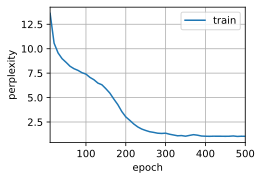

In [15]:
num_epochs, lr = 500, 1
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())

[**最後，讓我們檢查一下使用隨機抽樣方法的結果。**]


困惑度 1.5, 65222.3 词元/秒 cuda:0
time traveller held in his hand was a glitteringmetallic framewo
traveller but now you begin to seethe object of my investig


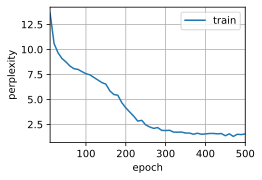

In [16]:
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                      init_rnn_state, rnn)
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu(),
          use_random_iter=True)

從零開始實現上述循環神經網路模型，
雖然有指導意義，但是並不方便。
在下一節中，我們將學習如何改進循環神經網路模型。
例如，如何使其實現地更容易，且運行速度更快。

## 小結

* 我們可以訓練一個基於循環神經網路字符級語言模型，根據用戶提供的文本的前綴生成後續文本。
* 一個簡單的循環神經網路語言模型包括輸入編碼、循環神經網路模型和輸出生成。
* 循環神經網路模型在訓練以前需要初始化狀態，不過隨機抽樣和順序分區使用初始化方法不同。
* 當使用順序分區時，我們需要分離梯度以減少計算量。
* 在進行任何預測之前，模型通過預熱期進行自我更新（例如，獲得比初始值更好的隱狀態）。
* 梯度裁剪可以防止梯度爆炸，但不能應對梯度消失。

## 練習

1. 嘗試說明獨熱編碼等價於為每個對象選擇不同的嵌入表示。
1. 通過調整超參數（如迭代週期數、隱藏單元數、小批量數據的時間步數、學習率等）來改善困惑度。
    * 困惑度可以降到多少？
    * 用可學習的嵌入表示替換獨熱編碼，是否會帶來更好的表現？
    * 如果用H.G.Wells的其他書作為數據集時效果如何，
      例如[*世界大战*](http://www.gutenberg.org/ebooks/36)？
1. 修改預測函數，例如使用采樣，而不是選擇最有可能的下一個字符。
    * 會發生什麼？
    * 調整模型使之偏向更可能的輸出，例如，當$\alpha > 1$，從$q(x_t \mid x_{t-1}, \ldots, x_1) \propto P(x_t \mid x_{t-1}, \ldots, x_1)^\alpha$中采樣。
1. 在不裁剪梯度的情况下運行本節中的代碼會發生什麼？
1. 更改順序分區，使其不會從計算圖中分離隱狀態。運行時間會有變化嗎？困惑度呢？
1. 用ReLU替換本節中使用的激活函數，並重複本節中的實驗。我們還需要梯度裁剪嗎？為什麼？


[Discussions](https://discuss.d2l.ai/t/2103)
